In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)

20.0

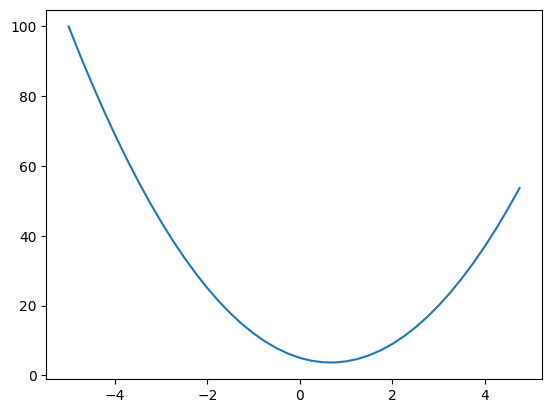

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

In [ ]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [ ]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)


d1 4.0
d2 4.0001
slope 0.9999999999976694


In [ ]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad 
    out._backward = _backward

    return out


  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

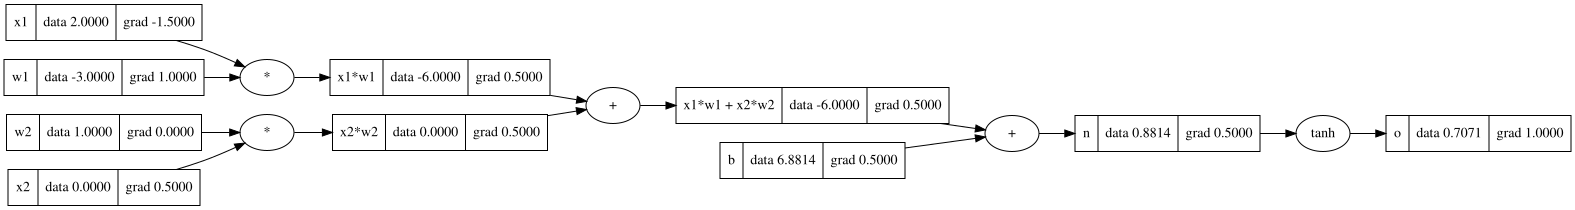

In [ ]:
draw_dot(o)

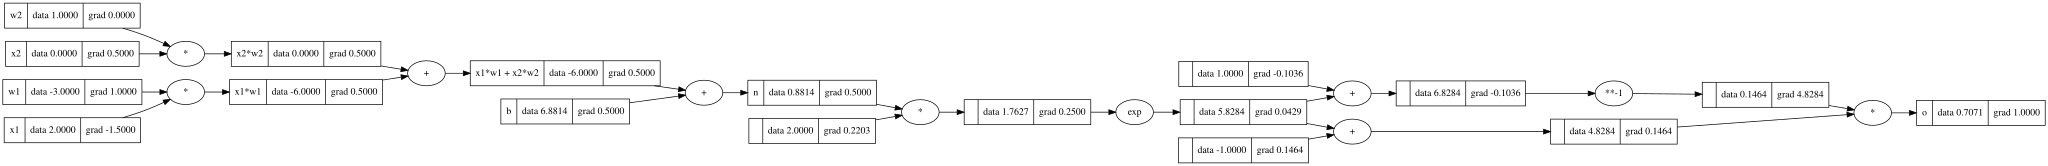

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()

o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [ ]:
import torch

In [ ]:

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

# stripping out the tensor to
# retrieve the element inside the tensor
print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


return [p for neuron in self.neurons for p in neuron.parameters()] = Nested List Comprehension.

Syntax = [item for sublist in main_list for item in sublist]

It's same as:

def parameters(self):
    # 1. Create an empty list to hold the results
    
    params = []
    
    # 2. Iterate through every neuron in this layer (The Outer Loop)
    for neuron in self.neurons:
        
        # 3. Get the list of parameters for THIS specific neuron
        # Example: neuron_params might be [w1, w2, b]
        neuron_params = neuron.parameters()
        
        # 4. Iterate through that list of parameters (The Inner Loop)
        for p in neuron_params:
            
            # 5. Add the individual parameter to our main list
            params.append(p)
            
    return params

In [ ]:
# A Neuron perform a linear transformation followed by
# a non-linearity (Activation function)
# output = tanh(Summation((w_i*x_i)+b))
class Neuron:

  def __init__(self, nin):
    # nin = number of inputs
    # Create a random weight (Value object) for every input
    # Initialized as Value objects. This is crucial.
    # Because it means the computation graph will track operations on them,
    # allowing us to calculate self.w[i].grad later
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    # Create a single bias (Value object)
    self.b = Value(random.uniform(-1,1))

  # __call__ method enables Python programmers ot write classes
  # where the instances behave like functions
  # and can be called like a function --> Example: e = Gfg() , e()
  def __call__(self, x):
    # w * x + b
    # x = input vector
    # 1. pair up weights and inputs (zip), zip used to combine multiple iterable objects
    # into a single iterable of tuples. Each tuple contains elements from the corresponding position of the input iterables
    # 2. Multiply them (wi*xi)
    # 3. Sum them all up, starting with the bias "b" as the initial accumulator, because:
    # sum() has a optional parameter which is the start and by default, start is 0
    # So these elements of this sum will be added on top of zero to begin with
    # but actually we can just start with self.b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    # Apply the activation function to introduce non-linearlity
    out = act.tanh()
    return out

  def parameters(self):
    # Return a flat list of all trainable parameters (weights + bias) in this neuron
    # List concatenation, [self.b] to turn it into a list containing one item
    return self.w + [self.b]

# A layer is simply a list of Neurons that operate independently on the same input
class Layer:

  def __init__(self, nin, nout):
    # nin = number of inputs coming into this layer
    # nout = number of neurons in this layer (the size of the layer)
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    # pass the input "x" to every neuron in this layer
    # Here is the __Call__ function working
    outs = [n(x) for n in self.neurons]

    # Convenience: if there is only 1 neuron, return the neuron directly
    # Otherwise return the list of neurons
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    # Gather parameters from all neurons in this layer into one flat list.
    # logic: [ [w,b] , [w,b] ] --> [w, b, w, b]
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    # nin = integer, number of inputs into the network
    # nouts = list of integers, defining the size of all subsequent layers

    # Combine input size with output sizes to get the full list of layers sizes
    # Example: nin = 3, nouts = [4,4,1] -> sz = [3,4,4,1]
    # 3 inputs into  2 layers of 4 and produces 1 output
    sz = [nin] + nouts

    # Create layer objects iterating through the sizes
    # Layer 1 connects sz[0] to sz[1], Layer 2 connects sz[1] to sz[2], etc.
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  # Mathematical expression grows significantly here, creating a massive DAG of Value Objects
  def __call__(self, x):
    # Forward Pass:
    # Sequentially pass the data through each layer.
    # The input 'x' is updated to be the output of the previous layer.
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    # Gather parameters from all layers into one massive flat list.
    # This is passed to the optimizer to update all weights in the network at once.
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
x = [2.0 , 3.0]
n = Neuron(2)
# return the value after the activation function
n(x)

Value(data=0.998774773896086)

In [ ]:
# Because you initialized Neruon(2) = with 2 weights
# and there will always be 1 bias
n.parameters()

[Value(data=0.2824865759019295),
 Value(data=0.8145707454625726),
 Value(data=0.6898967403971843)]

In [ ]:
x = [2.0 , 3.0]
n = Layer(2,3)
n(x)

[Value(data=0.9870621075681653),
 Value(data=0.8547692207953865),
 Value(data=-0.9993246736200732)]

In [ ]:
#
x = [2.0, 3.0, -1.0]
# three inputs into two layers of 4, and one output
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.20450394250203427)

In [ ]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [ ]:

for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  # n.parameters() will return a single, flat list containing value objects
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)


0 4.443371419995024
1 0.5205373495999612
2 0.14747535643116466
3 0.07544660826365016
4 0.05336812590902436
5 0.041616091901311145
6 0.034168885428301286
7 0.02899102388783887
8 0.0251717167871569
9 0.022234898771471286
10 0.019905330138016528
11 0.018012070227908607
12 0.01644307636464047
13 0.01512173946180481
14 0.013993856627352533
15 0.013019977418689346
16 0.012170695541617826
17 0.011423639575514118
18 0.01076148634256937
19 0.010170612420875594


In [ ]:
ypred

[Value(data=0.9396912643100473),
 Value(data=-0.9928411361957982),
 Value(data=-0.9511514384114822),
 Value(data=0.9359997068747283)]